# Train classic logistic regression models over clinical data from TCGA

## Goal

Get TCGA clinical data from GDC portal. Train a few logistic regression models to predict 5 year survival. i) Train a model using demographic features as input (age, sex, race, ethnicity and mortality), ii) Train a model using cancer type (TCGA cancer types) as input. Evaluate using AUC

## Analysis strategy
- Stratify dataset with TCGA cases by patient age, sex, race, ethnicity, mortality, and cancer type
- Discretize age into 20-year age bins for age stratification i.e. [0-20), [20-40), [40-60), [60-80), and 80+.
- Replace any missing values with "Not Reported"
- One-hot encode demographic features (age, sex, race, ethnicity) and TCGA cancer type
- Create binary labels for 5-year survival (1=survived, 0=died)
- Divide the data into 80% train and 20% test using 5-fold cross validation
- Fit Logistic regression models to the one-hot encoded features in train split
- Predict 5-yr survival on test splits and evaluate performance using mean AUC from 5-fold CV

## Multimodal fusion
- Concatenate the unimodal probabilities from cancer type and demographic models and use as input to train a multimodal fusion model (canc+demo)

### Save outputs

In [1]:
import os
os.makedirs('results', exist_ok=True)
output_predictions = "results/predictions_summarized.npy"

### Install libraries

In [2]:
!pip install pandas numpy tqdm scikit-learn scikit-survival matplotlib

### Import libraries

In [3]:
from itertools import chain, combinations
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

### Load clinical data from TCGA

In [4]:
df = pd.read_csv("clinical.csv")
clin_case_ids = set(df["case_id"])

In [5]:
df.shape

(8061, 9)

In [6]:
df.head(n=2)

,case_id,project,sex,age,race,ethnicity,vital_status,days_to_death,days_to_last_follow_up
0,TCGA-OR-A5J1,TCGA-ACC,male,58.893151,white,not reported,Dead,1355.0,1355.0
1,TCGA-OR-A5J2,TCGA-ACC,female,44.082192,white,hispanic or latino,Dead,1677.0,1677.0


In [7]:
df['sex'].unique()

array(['male', 'female'], dtype=object)

In [8]:
df['race'].unique()

array(['white', 'black or african american', 'not reported', 'asian',
       'Unknown', 'american indian or alaska native',
       'native hawaiian or other pacific islander'], dtype=object)

In [9]:
df['ethnicity'].unique()

array(['not reported', 'hispanic or latino', 'not hispanic or latino',
       'Unknown'], dtype=object)

In [10]:
df['vital_status'].unique()

array(['Dead', 'Alive'], dtype=object)

### Discretize age into bins

In [11]:
df["age_binned"] = pd.cut(
    df["age"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["(0, 20]", "(20, 40]", "(40, 60]", "(60, 80]", "(80, 100]"],
)

### Days to event is either days to death or days to last follow up

In [12]:
dead = df["vital_status"] == "Dead"
days_to_event = np.where(dead, df["days_to_death"], df["days_to_last_follow_up"])
assert not np.isnan(days_to_event).any()

In [13]:
y = np.array(list(zip(dead, days_to_event)), dtype=[('Status', '?'), ('Survival_in_days', '<f8')])

In [14]:
y

array([( True, 1355.), ( True, 1677.), (False, 2091.), ...,
       (False,  798.), ( True, 1396.), (False, 1184.)],
      dtype=[('Status', '?'), ('Survival_in_days', '<f8')])

### Create binary labels for 5-year survival prediction
- e.g. https://pmc.ncbi.nlm.nih.gov/articles/PMC12976663/

In [15]:
# e.g. https://pmc.ncbi.nlm.nih.gov/articles/PMC12976663/
cutoff_days = 5 * 365

# Create binary target: 1 = survived at least 5 years, 0 = died before 5 years
y_5yr = np.array([
    s['Survival_in_days'] >= cutoff_days or not s['Status']
    for s in y
], dtype=int)

In [16]:
y_5yr[:5]

array([0, 0, 1, 0, 1])

### More than 30% dead

In [17]:
pd.Series(y_5yr).value_counts()

1    6061
0    2000
Name: count, dtype: int64

### One hot encode demographics and cancer type

In [18]:
demo_ohe = OneHotEncoder(drop="if_binary", sparse_output=False, dtype=np.float32)
canc_ohe = OneHotEncoder(drop="if_binary", sparse_output=False, dtype=np.float32)

In [19]:
demo_ohe

OneHotEncoder(drop='if_binary', dtype=<class 'numpy.float32'>,
              sparse_output=False)

In [20]:
canc_ohe

OneHotEncoder(drop='if_binary', dtype=<class 'numpy.float32'>,
              sparse_output=False)

In [21]:
demo_X = demo_ohe.fit_transform(df[["sex", "age_binned", "race", "ethnicity"]])
canc_X = canc_ohe.fit_transform(df[["project"]])

### 17 unique demographic features

In [22]:
demo_X.shape

(8061, 17)

### 32 unique cancer types

In [23]:
canc_X.shape

(8061, 32)

In [24]:
demo_ohe.categories_

[array(['female', 'male'], dtype=object),
 array(['(0, 20]', '(20, 40]', '(40, 60]', '(60, 80]', '(80, 100]'],
       dtype=object),
 array(['Unknown', 'american indian or alaska native', 'asian',
        'black or african american',
        'native hawaiian or other pacific islander', 'not reported',
        'white'], dtype=object),
 array(['Unknown', 'hispanic or latino', 'not hispanic or latino',
        'not reported'], dtype=object)]

In [25]:
canc_ohe.categories_

[array(['TCGA-ACC', 'TCGA-BLCA', 'TCGA-BRCA', 'TCGA-CESC', 'TCGA-CHOL',
        'TCGA-COAD', 'TCGA-DLBC', 'TCGA-ESCA', 'TCGA-GBM', 'TCGA-HNSC',
        'TCGA-KICH', 'TCGA-KIRC', 'TCGA-KIRP', 'TCGA-LGG', 'TCGA-LIHC',
        'TCGA-LUAD', 'TCGA-LUSC', 'TCGA-MESO', 'TCGA-OV', 'TCGA-PAAD',
        'TCGA-PCPG', 'TCGA-PRAD', 'TCGA-READ', 'TCGA-SARC', 'TCGA-SKCM',
        'TCGA-STAD', 'TCGA-TGCT', 'TCGA-THCA', 'TCGA-THYM', 'TCGA-UCEC',
        'TCGA-UCS', 'TCGA-UVM'], dtype=object)]

### Set up 5-fold cross validation splits
- 5-fold CV tests
- for each fold, train model on all the data minus the fold, test model on the fold and evaluate using AUC
- save splits in a file

In [26]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splitter = (
    df["vital_status"]
    + "_"
    + df["project"]
    + "_"
    + df["sex"]
    + "_"
    + df["age_binned"].astype(str)
    + "_"
    + df["race"]
    + "_"
    + df["ethnicity"]
)

n = len(df)
test_splits = [split_idxs for _, split_idxs in skf.split(X=np.zeros(n), y=splitter)]

/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [27]:
splitter

0          Dead_TCGA-ACC_male_(40, 60]_white_not reported
1       Dead_TCGA-ACC_female_(40, 60]_white_hispanic o...
2       Alive_TCGA-ACC_female_(20, 40]_white_hispanic ...
3       Dead_TCGA-ACC_male_(20, 40]_white_hispanic or ...
4       Alive_TCGA-ACC_female_(20, 40]_black or africa...
                              ...                        
8056    Alive_TCGA-UVM_male_(60, 80]_white_not hispani...
8057    Alive_TCGA-UVM_female_(60, 80]_white_not hispa...
8058    Alive_TCGA-UVM_female_(40, 60]_white_not hispa...
8059    Dead_TCGA-UVM_female_(40, 60]_white_not hispan...
8060    Alive_TCGA-UVM_female_(40, 60]_white_not hispa...
Length: 8061, dtype: object

In [28]:
meta_df = df[["case_id"]].copy()
meta_df["split"] = -1
meta_df["split_order"] = -1
for i, test_idxs in enumerate(test_splits):
    meta_df.loc[test_idxs, "split"] = i
    meta_df.loc[test_idxs, "split_order"] = list(range(len(test_idxs)))
meta_df["dead"] = y["Status"]
meta_df["days_to_death_or_censor"] = y["Survival_in_days"]
meta_df.to_csv("results/split_cases.csv", index=False)

In [29]:
meta_df["split"].value_counts()

split
0    1613
1    1612
2    1612
3    1612
4    1612
Name: count, dtype: int64

In [30]:
test_splits

[array([   3,    9,   10, ..., 8054, 8057, 8058]),
 array([   0,    4,   11, ..., 8035, 8053, 8059]),
 array([   1,    5,   12, ..., 8041, 8044, 8056]),
 array([   2,    6,   16, ..., 8048, 8050, 8055]),
 array([   7,    8,   14, ..., 8049, 8051, 8060])]

### Set up model training

In [31]:
def run_split(
    *,  # enforce kwargs
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    pca_components: int or None,
    standardize: bool,
    name: str = "",
    verbose: bool = False,
) -> dict:
    if verbose:
        print(f"Running {name}")

    # z-score input features
    if standardize:
        if verbose:
            print("--standardized")
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test

    # dimensionality reduction
    if pca_components is not None:
        if verbose:
            print("--reduced")
        pca = PCA(n_components=pca_components, random_state=42)
        X_train_red = pca.fit_transform(X_train_scaled)
        X_test_red = pca.transform(X_test_scaled)
    else:
        X_train_red = X_train_scaled
        X_test_red = X_test_scaled
    

    # fit logistic regression on the training split
    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_train_red, y_train)  # y_train_5yr: 0/1 labels for 5-year survival

    # generate predicted probabilities for class 1 (survival = 1) on train and test
    y_train_pred = logreg.predict_proba(X_train_red)[:, 1]
    y_test_pred = logreg.predict_proba(X_test_red)[:, 1]

    # evaluate predictions on test using AUC
    auc_score = roc_auc_score(y_test, y_test_pred)  # y_test: 0/1 labels

    return {
        "auc": auc_score,
        "y_test_pred": y_test_pred,
        "y_train_pred": y_train_pred,
        "y_test": y_test
    }


def run_unimodal_split(
    *,  # enforce kwargs
    X: np.ndarray,
    y: np.ndarray,
    test_idxs: np.ndarray,
    train_idxs: np.ndarray,
    pca_components: int or None,
    standardize: bool,
    name: str = "",
    verbose: bool = False,
) -> dict:
    # split matrices
    X_train, X_test = X[train_idxs], X[test_idxs]
    y_train, y_test = y[train_idxs], y[test_idxs]

    return run_split(
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        pca_components=pca_components,
        standardize=standardize,
        name=name,
        verbose=verbose,
    )

def powerset(s):
    return chain.from_iterable(combinations(s, r) for r in range(len(s)+1))

In [32]:
def run_experiment(pca_components: int) -> dict:
    results = []
    for test_idxs in tqdm(test_splits, desc="Cross Validation Splits"):
        split_results = dict()

        temp = set(test_idxs)
        train_idxs = [i for i in range(n) if i not in temp]

        split_results["demo"] = run_unimodal_split(X=demo_X, y=y_5yr, test_idxs=test_idxs, train_idxs=train_idxs, pca_components=None, standardize=False)
        split_results["canc"] = run_unimodal_split(X=canc_X, y=y_5yr, test_idxs=test_idxs, train_idxs=train_idxs, pca_components=None, standardize=False)
        
        y_train, y_test = y_5yr[train_idxs], y_5yr[test_idxs]

        # fusion model (canc + demo)
        combos = [sorted(x) for x in powerset(["demo", "canc"]) if len(x) > 1]
        for combo in combos:
            mult_X_train = []
            mult_X_test = []
            for modality in combo:
                x_train = split_results[modality]["y_train_pred"][:, np.newaxis]
                x_test = split_results[modality]["y_test_pred"][:, np.newaxis]
                # z-score all unimodal risks
                scaler = StandardScaler()
                x_train = scaler.fit_transform(x_train)
                x_test = scaler.transform(x_test)
                mult_X_train.append(x_train)
                mult_X_test.append(x_test)

            mult_X_train = np.concatenate(mult_X_train, axis=1)
            mult_X_test = np.concatenate(mult_X_test, axis=1)

            split_results["-".join(combo)] = run_split(X_train=mult_X_train, y_train=y_train, X_test=mult_X_test, y_test=y_test, pca_components=None, standardize=False)

        results.append(split_results)
    return results

### Run training, save results and predictions

In [33]:
results = dict()
pca_components = 'pca-none'
results[pca_components] = run_experiment(pca_components=None)
np.save(output_predictions, results)

Cross Validation Splits: 100%|██████████| 5/5 [00:00<00:00, 23.03it/s]


In [34]:
len(results['pca-none'])

5

In [35]:
results['pca-none'][:1]

[{'demo': {'auc': np.float64(0.6416900064696297),
   'y_test_pred': array([0.90175111, 0.70451029, 0.84510336, ..., 0.7447997 , 0.7447997 ,
          0.82033121]),
   'y_train_pred': array([0.70451029, 0.8554643 , 0.93124352, ..., 0.66417408, 0.82033121,
          0.82033121]),
   'y_test': array([0, 0, 0, ..., 0, 1, 1])},
  'canc': {'auc': np.float64(0.7388265811692832),
   'y_test_pred': array([0.71950443, 0.71950443, 0.71950443, ..., 0.71110247, 0.71110247,
          0.71110247]),
   'y_train_pred': array([0.71950443, 0.71950443, 0.71950443, ..., 0.71110247, 0.71110247,
          0.71110247]),
   'y_test': array([0, 0, 0, ..., 0, 1, 1])},
  'canc-demo': {'auc': np.float64(0.7514116486090296),
   'y_test_pred': array([0.83272526, 0.73234294, 0.80739469, ..., 0.74685609, 0.74685609,
          0.78769941]),
   'y_train_pred': array([0.73234294, 0.8122367 , 0.84482295, ..., 0.69788727, 0.78769941,
          0.78769941]),
   'y_test': array([0, 0, 0, ..., 0, 1, 1])}}]

In [36]:
indiv_combos = ["canc", "demo"]
fusion = '-'.join(indiv_combos)
print(fusion)

canc-demo


### Plot results

------------------


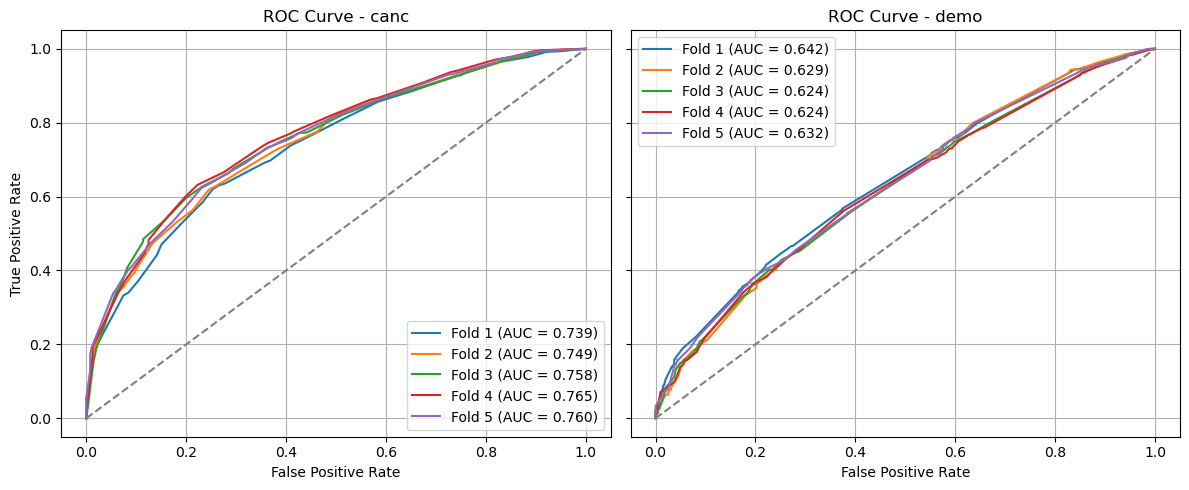

In [37]:
print("------------------")
for pca_components in ['pca-none']:
    
    fig, axes = plt.subplots(1, len(indiv_combos), figsize=(12, 5), sharex=True, sharey=True)

    # set up axes
    for j, combo in enumerate(indiv_combos):
        ax = axes[j]

        for i in range(5):
            y_prob = results[pca_components][i][combo]['y_test_pred']
            y_test = results[pca_components][i][combo]['y_test']

            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc_score = results[pca_components][i][combo]['auc']

            ax.plot(fpr, tpr, label=f"Fold {i+1} (AUC = {auc_score:.3f})")

        # diagonal baseline
        ax.plot([0, 1], [0, 1], linestyle="--", color="gray")

        ax.set_xlabel("False Positive Rate")
        if j == 0:
            ax.set_ylabel("True Positive Rate")

        ax.set_title(f"ROC Curve - {combo}")
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

### Mean AUCs from 5-fold cross validation

In [38]:
print("Unimodal Results")
print("------------------")
for pca_components in tqdm(['pca-none']):
    for combo in indiv_combos:
        auc_list = []
        for i in range(5):
            auc = results[pca_components][i][combo]["auc"]
            auc_list.append(auc)
        mean_auc = np.mean(auc_list)
        print(f'Mean AUC {combo}:{mean_auc}')

print("Multimodal Results")
print("------------------")
for pca_components in tqdm(['pca-none']):
    for combo in [fusion]:
        auc_list = []
        for i in range(5):
            auc = results[pca_components][i][combo]["auc"]
            auc_list.append(auc)
        mean_auc = np.mean(auc_list)
        print(f'Mean AUC {combo}:{mean_auc}')

Unimodal Results
------------------


100%|██████████| 1/1 [00:00<00:00, 5269.23it/s]


Mean AUC canc:0.7541436453872289
Mean AUC demo:0.6300838915902462
Multimodal Results
------------------


100%|██████████| 1/1 [00:00<00:00, 6955.73it/s]

Mean AUC canc-demo:0.7622891533147156
